<a href="https://colab.research.google.com/github/nainikadevireddy/JohnsHopkinsAI/blob/main/Deep%20Neural%20Networks/DiamondsCompetition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<small><font color=gray>Notebook author: <a href="https://www.linkedin.com/in/olegmelnikov/" target="_blank">Oleg Melnikov</a> ©2021 onwards</font></small><hr style="margin:0;background-color:silver">

**<font size=6>💎Diamonds</font>**. [**Instructions**](https://colab.research.google.com/drive/1riOGrE_Fv-yfIbM5V4pgJx4DWcd92cZr#scrollTo=ITaPDPIQEgXV) for running Colabs.

<small>**(Optional) CONSENT.** <mark>[ X ]</mark> We consent to sharing our Colab (after the assignment ends) with other students/instructors for educational purposes. We understand that sharing is optional and this decision will not affect our grade in any way. <font color=gray><i>(If ok with sharing your Colab for educational purposes, leave "X" in the check box.)</i></font></small>

In [ ]:
from google.colab import drive; drive.mount('/content/drive')   # OK to enable, if your kaggle.json file is stored in Google Drive

Mounted at /content/drive


In [ ]:
!pip install --upgrade --force-reinstall --no-deps kaggle > log  # upgrade kaggle package (to avoid a warning)
!mkdir -p ~/.kaggle                                           # .kaggle folder must contain kaggle.json for kaggle executable to properly authenticate you to Kaggle.com
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json >log  # First, download kaggle.json from kaggle.com (in Account page) and place it in the root of mounted Google Drive
!cp kaggle.json ~/.kaggle/kaggle.json > log                   # Alternative location of kaggle.json (without a connection to Google Drive)
!chmod 600 ~/.kaggle/kaggle.json                              # give only the owner full read/write access to kaggle.json
!kaggle config set -n competition -v 21jan25-diamonds         # set the competition context for the next few kaggle API calls. !kaggle config view - shows current settings
!kaggle competitions download >> log                          # download competition dataset as a zip file
!unzip -o *.zip >> log                                        # Kaggle dataset is copied as a single file and needs to be unzipped.
!kaggle competitions leaderboard --show                       # print public leaderboard

cp: cannot stat 'kaggle.json': No such file or directory
- competition is now set to: 21jan25-diamonds
100% 3.30M/3.30M [00:01<00:00, 2.74MB/s]
Using competition: 21jan25-diamonds
  teamId  teamName                       submissionDate       score            
--------  -----------------------------  -------------------  ---------------  
13244663  1 Oluwatobi_Daniel_David       2025-02-02 19:23:21  568.2412025000   
13256813  12_Nainika_Arvin_Jenelle       2025-02-02 02:17:51  585.7401800000   
13244737  💎 10                           2025-02-02 01:35:57  609.3773099999   
13256842  Team 3 Shuai & Casimir         2025-02-02 22:18:05  624.7296609999   
13203520  JacobMarx                      2025-02-02 14:17:41  648.1720905000   
13275591  2 Kumar Ray Josh               2025-02-02 15:22:53  652.2266264999   
13240845  7_Austin_Madihah               2025-02-02 22:15:39  657.1328300000   
13265250  11.Shunguan&JungWooJamesJeong  2025-02-02 06:07:43  659.4000059999   
13271090  Sichao Liu

In [ ]:
%%time
%%capture
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, seaborn as sns, os, tqdm, re, sys, cv2, skimage
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals
os.environ['TF_DETERMINISTIC_OPS'] = '1'; os.environ['TF_CUDNN_DETERMINISTIC'] = '1'; # allows seeding RNG on GPU

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=100, precision=2, edgeitems=2, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)
tDIR, sDIR = 'trainXY/', 'testY/'

CPU times: user 1.29 s, sys: 140 ms, total: 1.43 s
Wall time: 1.51 s


In [ ]:
df = pd.read_csv('XY_diamonds.csv'); df

,carat,depth,table,x,y,z,cut,color,clarity,price
0,0.35,67.2,57.1,4.64,4.69,2.87,I,G,VS1,NaN
1,1.64,67.3,60.7,7.84,7.82,4.94,V,E,SI1,NaN
...,...,...,...,...,...,...,...,...,...,...
199998,0.48,68.7,53.0,4.47,4.45,2.72,I,G,IF,1474.0
199999,0.48,65.0,64.7,5.60,5.62,3.44,I,H,VS2,765.0


In [ ]:
df.price.info()

<class 'pandas.core.series.Series'>
RangeIndex: 200000 entries, 0 to 199999
Series name: price
Non-Null Count   Dtype  
--------------   -----  
160000 non-null  float64
dtypes: float64(1)
memory usage: 1.5 MB


In [ ]:
vX = df.query('price!=price').drop('price', axis=1)  # slice a test sample
tXY = df.query('price==price')                       # slice training sample
tX, tY = tXY.drop('price', axis=1), tXY.price        # split into training I/O

In [ ]:
def ScatterCorrHist(df):
  def corrdot(*args, **kwargs):
    # credit: https://stackoverflow.com/questions/48139899
    corr_r = args[0].corr(args[1], 'pearson')
    corr_text = f"{corr_r:2.2f}".replace("0.", ".")
    ax = plt.gca();
    ax.set_axis_off();
    msz = abs(corr_r) * 5000   # marker size
    fsz = abs(corr_r) * 40 + 5 # font size
    ax.scatter([.5], [.5], msz, [corr_r], alpha=0.5, cmap='coolwarm', vmin=-1, vmax=1, transform=ax.transAxes)
    ax.annotate(corr_text, [.5, .5,],  xycoords="axes fraction", ha='center', va='center', fontsize=fsz)

  sns.set(style='white', font_scale=.8);
  g = sns.PairGrid(df, aspect=1, diag_sharey=False);
  g.fig.set_size_inches(20,10)
  g.map_lower(sns.regplot, lowess=True, ci=False, line_kws={'color':'red'}, scatter_kws={'s':1});
  g.map_diag(sns.histplot, kde_kws={'color':'black'});
  g.map_upper(corrdot);
  g.fig.suptitle("Scatter plot, Correlations and histograms on diagonal", y=1);
  _ = plt.subplots_adjust(hspace=0.02, wspace=0.02);
  _ = plt.show();

#ScatterCorrHist(tXY.head(200))  # takes a minute time to run

In [ ]:
tmr = Timer()

⏳ started. You have 60 sec. Good luck!


<hr color=green size=40>

<strong><font color=green size=5>⏳Timed Green Playground (TGP): Your ideas, code, documentation, and timer START HERE!</font></strong>

<font color=green>Students: Keep all your definitions, code, documentation in <b>TGP</b>. Modifying any code outside of TGP incurs penalties.

Please use T4 GPU (free) to run this!

<font color=green><h3><b>Import Necessary Libraries</b><h3>






In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.interpolate import interp1d

<font color=green><h3><b>Categorical to Ordinal Features</b><h3>

In [ ]:
def categorical_features(X):
  #Encodes ordinal categorical variables (cut, color, clarity) using industry-standard diamond ratings

  #Cut Ranking: Ideal, Premium, Very Good, Good, Fair (from best to worst)
  cut_encoder = OrdinalEncoder(categories=[['F', 'G', 'V', 'P', 'I']])
  X['cut'] = cut_encoder.fit_transform(X[['cut']])

  #Color Ranking: D, E, F, G, H, I, J (from best to worst)
  color_encoder = OrdinalEncoder(categories=[['J', 'I', 'H', 'G', 'F', 'E','D']])
  X['color'] = color_encoder.fit_transform(X[['color']])

  #Clarity Ranking: IF, VVS1, VVS2, VS1, VS2, SI1, SI2, I1 (from best to worst)
  clarity_encoder = OrdinalEncoder(categories=[['I1','SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']])
  X['clarity'] = clarity_encoder.fit_transform(X[['clarity']])

  return X


In [ ]:
# Apply Ordinal Encoding to Features
tX = categorical_features(tX)
vX = categorical_features(vX)

<font color=green><h3><b>Feature Engineering</b><h3>


In [ ]:
def feature_engineering(X):
  #Creates new features

  # Substitute zero values in x, y, z with very small value to avoid division by zero error
  X[['x', 'y', 'z']] = np.where(X[['x', 'y', 'z']] == 0, 1e-9, X[['x', 'y', 'z']])

  X['table_x_ratio'] = X['table'] / X['x']
  X['depth_x_ratio'] = X['depth'] / X['x']
  X['carat_depth_ratio'] = X['carat'] / X['depth']

  X['volume'] = X['x'] * X['y'] * X['z']
  X.drop(columns=['x', 'y', 'z'], inplace=True)

  return X

In [ ]:
# Apply Feature Engineering
tX = feature_engineering(tX)
vX = feature_engineering(vX)

<font color=green><h3><b>Feature Transformation</b><h3>


In [ ]:
def feature_transformation(X):
    # Applies non-linear transformation to better capture feature relationships

    X['log_clarity'] = np.log1p(X['clarity'])
    X['log_table_x_ratio'] = np.log1p(X['table_x_ratio'])
    X['log_depth_x_ratio'] = np.log1p(X['depth_x_ratio'])
    X['log_carat_depth_ratio'] = np.log1p(X['carat_depth_ratio'])

    X['exp_cut'] = np.expm1(np.clip(X['cut'], a_min=None, a_max=1000))
    X['exp_color'] = np.expm1(np.clip(X['color'], a_min=None, a_max=1000))

    X['sqrt_carat'] = np.sqrt(X['carat'])
    X['sqrt_depth'] = np.sqrt(X['depth'])
    X['sqrt_table'] = np.sqrt(X['table'])
    X['sqrt_volume'] = np.sqrt(X['volume'])


    return X

In [ ]:
# Apply Feature Transformation
tX = feature_transformation(tX)
vX = feature_transformation(vX)

<font color=green><h3><b>Polynomial Features and Scaling</b><h3>


In [ ]:
# Using Polynomial Expansion to capture complex relationships between features
poly = PolynomialFeatures(degree=3)
tX_in = poly.fit_transform(tX.select_dtypes(include=np.number))
vX_in = poly.transform(vX.select_dtypes(include=np.number))

# Using StandardScaler for feature standardization
scaler = StandardScaler()
tX_in = scaler.fit_transform(tX_in)
vX_in = scaler.transform(vX_in)

<font color=green><h3><b>Sampling Training Data</b><h3>


In [ ]:
# Convert training data to dataframe
feature_names = poly.get_feature_names_out()
tX_in = pd.DataFrame(tX_in, columns=feature_names)


np.random.seed(42)

# Stratified Sampling
n_samples = 70000
price_bins = pd.qcut(tY, q=10, labels=False)
sample_idx = []

for bin_id in range(10):
    bin_indices = np.where(price_bins == bin_id)[0]
    bin_sample = np.random.choice(bin_indices, size=n_samples//10, replace=False)
    sample_idx.extend(bin_sample)

tX_sub = tX_in.iloc[sample_idx].copy()
tX_sub = np.array(tX_sub)
tY_sub = tY.iloc[sample_idx].copy()

<font color=green><h3><b>Fit Model to Training Dataset</b><h3>

In [ ]:
# Model Training
m = LinearRegression()
m.fit(tX_sub, tY_sub)

LinearRegression()

<font color=green><h3><b>Prediction of Test Dataset using Trained Model</b><h3>

In [ ]:
# Making Predictions
pY = pd.DataFrame(m.predict(vX_in), index=range(1,len(vX)+1), columns=['price'])

<font color=green><h3><b>Post-Prediction Processing</b><h3>

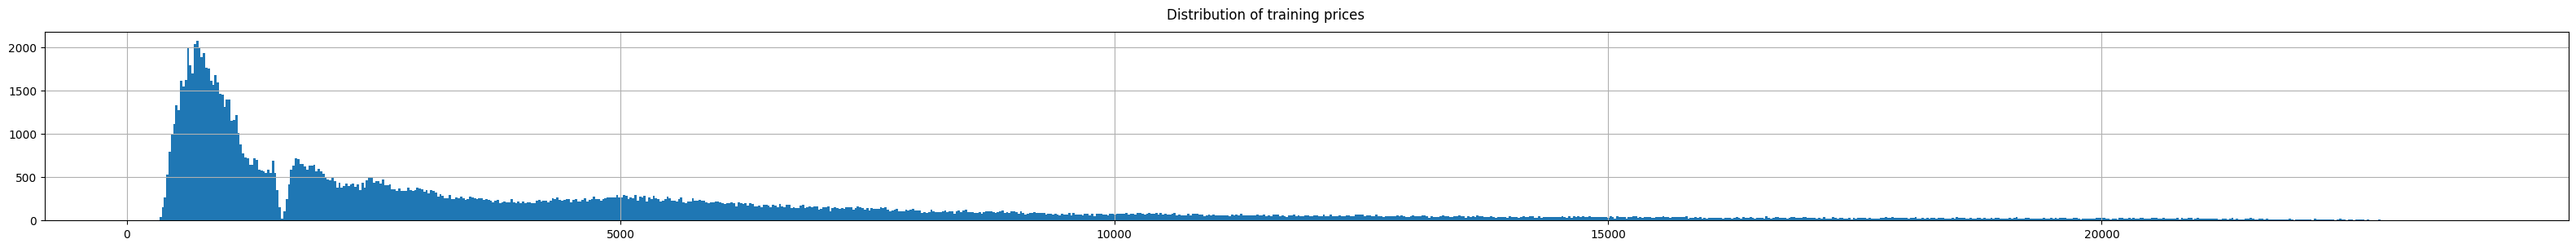

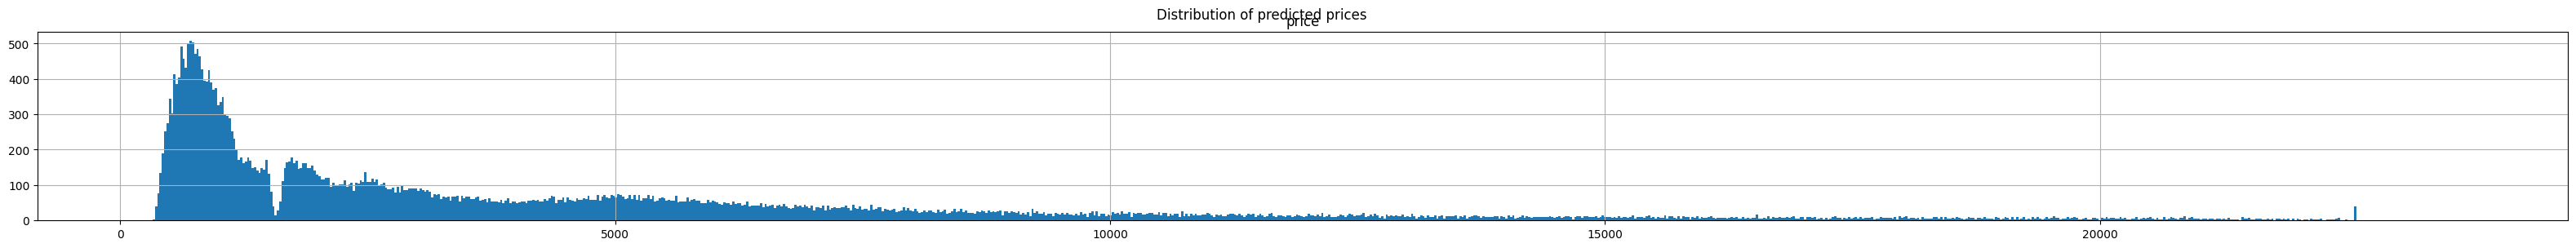

In [ ]:
# Align predicted price distribution to matching training data distribution
from scipy.interpolate import interp1d
train_quantiles = np.quantile(tY, np.linspace(0, 1, 1000))
pred_quantiles = np.quantile(pY['price'], np.linspace(0, 1, 1000))
transform_func = interp1d(pred_quantiles, train_quantiles,
                         bounds_error=False,
                         fill_value=(train_quantiles[0], train_quantiles[-1]))

# Apply the transformation to adjust predictions
pY['price'] = transform_func(pY['price'])

# Clip prices to a reasonable ranfe and output final predictions
pY = pY.clip(lower=10)
_ = tY.hist(figsize=(40,3), bins=1000);  _ = plt.suptitle("Distribution of training prices");
_ = pY.hist(figsize=(40,3), bins=1000);  _ = plt.suptitle("Distribution of predicted prices");
ToCSV(pY, 'resultWithPostprocess')

In [ ]:
# Used for 5-Cross Validation of Model

#from sklearn.model_selection import cross_val_score, KFold
#from sklearn.metrics import mean_absolute_error, make_scorer
#from sklearn.linear_model import Ridge, Lasso

## Polynomial Feature Transformation
#poly = PolynomialFeatures(degree=3)
#tX = poly.fit_transform(tX.select_dtypes(include=np.number))

## Get feature names from PolynomialFeatures
#feature_names = poly.get_feature_names_out()
#tX = pd.DataFrame(tX, columns=feature_names)

## Scale the features
#scaler = MinMaxScaler()
#tX = scaler.fit_transform(tX)

## Custom MAE scorer for cross-validation
#mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

## Define cross-validation strategy
#cv = KFold(n_splits=5, shuffle=True, random_state=42)

## Initialize Models
#models = {
#    "Linear Regression": LinearRegression(),
#    "Ridge Regression (alpha=0.01)": Ridge(alpha=0.01),
#    "Ridge Regression (alpha=0.001)": Ridge(alpha=0.001),
#    "Ridge Regression (alpha=0.0001)": Ridge(alpha=0.0001)
#}

## Store results
#results = {}

## Perform cross-validation for each model with post-processing
#for name, model in models.items():
#    fold_maes = []  # Store MAE for each fold

#    for train_index, test_index in cv.split(tX):
#        # Split data into training and testing
#        X_train, X_test = tX[train_index], tX[test_index]
#        y_train, y_test = tY.iloc[train_index], tY.iloc[test_index]

#        # Train the model
#        model.fit(X_train, y_train)

#        # Predict on the test set
#        y_pred = model.predict(X_test)

#        # Post-Prediction Processing
#        train_quantiles = np.quantile(y_train, np.linspace(0, 1, 1000))
#        pred_quantiles = np.quantile(y_pred, np.linspace(0, 1, 1000))
#        transform_func = interp1d(pred_quantiles, train_quantiles,
#                                  bounds_error=False,
#                                  fill_value=(train_quantiles[0], train_quantiles[-1]))
#        y_pred_adjusted = transform_func(y_pred)

#        # Calculate MAE for this fold
#        fold_mae = mean_absolute_error(y_test, y_pred_adjusted)
#        fold_maes.append(fold_mae)

#    # Store mean and standard deviation of MAE across folds
#    results[name] = {
#        "MAE Mean": np.mean(fold_maes),
#        "MAE Std Dev": np.std(fold_maes)
#    }

# Convert results to a DataFrame for better visualization
#results_df = pd.DataFrame(results).T

# Print the results
#print(results_df)


<font color=green><h3><b>$\epsilon$. Idea Documentation (JHU students only)</b></h3>
<details>
  <summary>Instructions</summary>
  <div>


1. **Audience**. Your peers who will learn from your Colab and ideas therein.
1. **Importance**. The ML/DL ideas are not entirely random, but are based on prior experience and systematized/organized experiments. We'd like students to share and learn from idea generation to idea experimentation process done in our class using tools learned thus far.
1. **Format**. Keep it concise/precise in consistent font/presentation. Include numbers/IDs to your References, such as [1] or [[Géron22]](https://scholar.google.com/scholar?cluster=498861685923226475), where these are defined in your References section below. This helps link your ideas/experiments to external ideas.
1. **Reproducibility**. Your description should contain reasonable details needed for reproducibility, i.e. describe the state of your modeling pipeline before the change is made, what is changed and how the idea was discovered, and what improvement it resulted in. Thus, peers can try this idea with an expectation of the value it brings. See examples below.
1. **Bonus** points for the exceptional/exemplary/educational documentation (see grading rubric).
****
1. **TODO**: Describe the key idea in your work in the following format (similar to a "micro publication"):
  1. **Title**. Give each idea a descriptive name (i.e. a micro abstract).
    1. Ex(ample). <i>"Thresholding carat feature outliers improves MAE by 3% on public LB"</i>
  1. **Idea Discovery**. What led you to this idea? Was it some [EDA](https://en.wikipedia.org/wiki/Exploratory_data_analysis), familiarity with this dataset or some of the features?
    1. Ex. <i>"We plotted all univariate distributions of variables and discovered that diamond carat had unreasonable (but rare) values below and above [0,10] interval, when plotted carat's histogram in the train and test sets, which contained 10 and 3 such outliers respectively. We decided to use 10 as a reasonable threshold because it is 99th percentile of carat values in the 20K baseline sample. See our histogram plot below [plot here]. "</i>
  1. **Finding's Importance**. Describe why you think the idea was important to proceed with.
    1. Ex. <i>"We use a linear model, the slope of which is sensitive to outliers on the periphery of the feature space domain. The fitted hyperplane slopes in the direction of the extreme training feature values thereby mapping a non-existent relation between carat size and diamond price, which is not expected to repeat in the test set. "</i>
  1. **Experiment Setup**.
  How did you set up experiments to test your idea? What resources were helpful? What metric did you select, why and what values did you observe?
    1. Ex. <i>"To alleviate the impact of the outlying feature values, we need to either remove observations with extreme values, or somehow cap them (to stay within the distribution of the other carat values) or use a model insensitive to outliers (such as robust regression). We learned 3 suitable methods for treating outliers in [ref]: ... [It'd be great to briefly describe each method] We tried each one on a Baseline model, while keeping the competition-required [MAE](https://en.wikipedia.org/wiki/Mean_absolute_error) metric. We tested each method locally on the seeded 50/50 split of the 20K training set sampled in baseline Colab."</i>
  1. **Results**. What was the result or metric improvement from implementing the experiment locally and/or on public LB?
    1. Ex. <i>"Baseline MAE was 539.1257546465 in public LB and 530 in local default experiment with 50/50 train-test split. When applied on the same-seed split, Methods 1,2,and 3 showed 1%, 2%, and 5% improvement on the test set. When uploaded to public LB, Method 3 showed a 3% improvement. So, we decided to keep method 3."</i>

</div> </details>
</font>


<font color=green><h4><b>Task 1. Preprocessing Ideas</b></h4>
<details>
  <summary>Instructions</summary>
  <div>Explain a <b>key idea</b> that helped in <b>preprocessing pipeline</b>. This may be about some feature engineering, tricky subsampling, clustering, dimension reduction, etc. Use the format in TODO specified above. Remember to provide citation references for the peers to read more into your work.
</div> </details>
</font>

1. **Title**: Ordinal Encoding vs. Alternative Encodings of Categorical Features
1. **Idea Discovery**: We explored different encoding methods for categorical variables: cut, color, and clarity. We researched the industry standard grading of the three features according to the Gemological Institute of America (GIA) and the International Gemological Institute (IGI) to establish ordinal encoding. In addition to this, we tested target encoding and frequency encoding; however, only ordinal encoding yielded improvements.
1. **Finding's Importance**: Ordinal encoding preserves the rank order of categorical variables, ensuring that the relationship between cut, color, clarity, and price remains interpretable. The GIA standard for color rankings follows the order of D, E, F, G, H, I, and J (best to worst). The GIA standard for clarity rankings follows the order of IF, VVS1, VVS2, VS1, VS2, SI1, SI2, and I1 (best to worst) [1]. The dataset does not explicitly define the full names of the cut grades, using only 'I,' 'G,' 'V,' 'F,' and 'P' as labels. The industry-standard grading scales from GIA and IGI follow 'Excellent, Very Good, Good, Fair, Poor' which do not align with the datasets. Price-based analysis of the dataset's categories suggests that the provided labels align more closely with the commonly used classification of 'Ideal, Premium, Very Good, Good, and Fair.'
1. **Experiment Setup**: We used five-fold cross-validation with the Linear Regression model as a baseline and measured performance using Mean Absolute Error (MAE) to determine the ideal approach.

1. **Results**: Target encoding and frequency encoding did not lead to any improvements. Ordinal encoding using IGI and GIA rankings resulted in a decrease in MAE by 9. Due to its improved performance, ordinal encoding was finalized for categorical variables.

1. **Title**: Log/Sqrt/Exp Transformations for Improved Feature Distributions
1. **Idea Discovery**: Exploratory data analysis revealed skewed distributions in carat (see histograms in Findings Importance section below), depth, table, and volume. To normalize these distributions and improve model stability, we applied log, square root, and exponential transformations.
1. **Finding's Importance**: These transformations reduce the impact of outliers and extreme values, helping linear models generalize better by maintaining scale consistency. We initially attempted z-score outlier removal and interquartile range (IQR) removal, but these methods eliminated valuable data points, leading to increased MAE. Instead, we adopted log, square root, and exponential transformations to better handle skewed distributions without discarding important information. Furthermore, linear regression assumes a linear relationship between input and output [2], but skewed data introduces a nonlinear pattern.
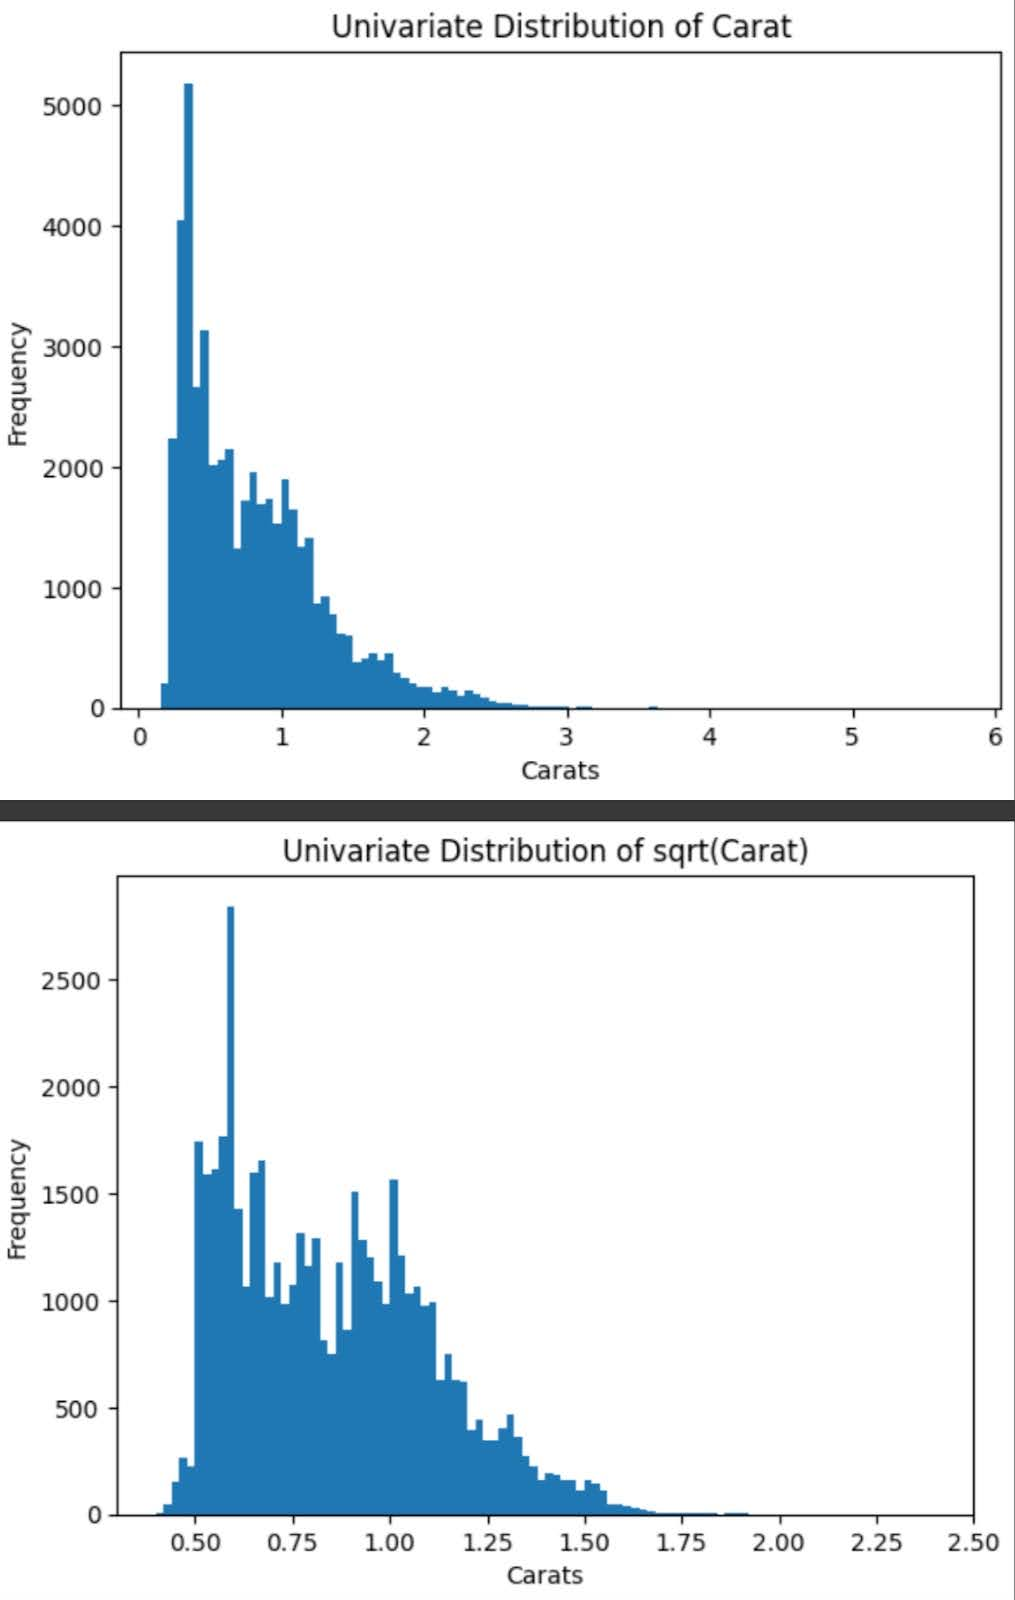

1. **Experiment Setup**: We used five-fold cross-validation with the Linear Regression model as a baseline and measured performance using Mean Absolute Error (MAE). To validate the effects of the transformations, we analyzed histograms and scatterplots of the transformed features to assess overall linearity. We also computed skewness and kurtosis before and after transformations to quantify shifts in distribution. Changes in Pearson correlation coefficients with price were examined to verify improved linearity.

1. **Results**: Without transformations, the MAE was 932.73, showed instability in the model due to non-normalized features. After applying the log1p transformation to clarity, table_x ratio, depth_x ratio and carat/depth ratio, the square root transformation to carat, depth, table, and volume, and the expm1 transformation to cut and color, the MAE improved to 594.31. The reduction in skewness, and improved linear relationships all contributed to better predictive performance.

1. **Title**: Transforming Carat Feature Using Square Root Improves MAE by 9.22%
1. **Idea Discovery**: We plotted the univariate distributions of each input variable. We found that the distribution for the carat variable was right-skewed (see histogram under Finding's Importance in the section above).
1. **Finding's Importance**: The linear model used can be highly-impacted by skewed data. Linear regression assumes a linear relationship between input and output [2], but skewed data introduces a nonlinear pattern. With right skew, the model risks overestimating the prices for cheap diamonds, while still underestimating the very expensive diamonds to satisfy the loss function. To mitigate this scenario, we include a transformed value of the carat variable as an input feature (see the difference in histograms under Finding's Importance in the section above), and thus,this experiment focuses on choosing the best transform to use.
1. **Experiment Setup**: To alleviate the issue of the right-skewed training data, we set up an experiment to compare the impact of various transformations on Mean Absolute Error (MAE). We measured performance on a 70/30 train-test split on the 160K labeled points in the dataset with MAE. In this blog post [3], we found various methods for handling skewed data. We chose to experiment with 3 transforms: square root (moderate), log (higher), inverse (extreme). These methods were compared to a Baseline model. We test each metric with 4 different train/test seeds (random_state=1, 2, 3, and 4 were used).
1. **Results**: For each random seed, we show the baseline MAE and MAE associated with each transform:

    random_state=1:
        Baseline: 898.49
        Square Root: 723.32
        Log: 706.53
        Inverse: 749.52
    random_state=2:
        Baseline: 655.04
        Square Root: 676.04
        Log: 700.88
        Inverse: 674.02
    random_state=3:
        Baseline: 671.62
        Square Root: 652.38
        Log: 698.88
        Inverse: 679.61
Each method showed improvement to the baseline in at least one case. However, the MAE was lowest, on average across seeds, for the square root transform. Therefore, we selected square root which showed an average MAE improvement of 9.22% over baseline on a locally held-out set.


1. **Title**: Feature Engineering
1. **Idea Discovery**: To improve predictive performance, we explored various feature engineering techniques to capture substantial relationships between diamond characteristics and price. Initial investigations focused on ratio-based transformations, including depth/table, carat/depth, and volume, as well as interactions between categorical attributes such as cut, color, and clarity. Through experimentation, we determined that the depth-to-table ratio did not improve model performance, while the carat-to-depth ratio and volume helped reduce redundancy and improved predictions. Additionally, we introduced depth-to-x (depth/x) and table-to-x (table/x) ratios, which further refined the model's ability to capture diamond proportions that influence pricing.

1. **Finding's Importance**: Each added feature contributes meaningful information relevant to diamond pricing. The carat-to-depth ratio captures how the diamond’s weight is distributed relative to its depth, affecting brilliance, light reflection, and perceived size, with poor ratios making diamonds appear dull or smaller than expected for their weight. The volume feature, calculated as x * y * z, consolidates the given dimensions into a single metric, reducing redundancy in the dataset, while accurately depicting the size. The depth-to-x (depth/x) ratio reflects the diamond’s depth relative to its width, influencing how light interacts with the stone that contributes to the fire, brilliance, and scintillation of the diamond [4][5]. Similarly, the table-to-x (table/x) ratio serves as an approximation of the table percentage, a key determinant in diamond grading due to its effect on light dispersion [4][5].

1. **Experiment Setup**: We used five-fold cross-validation with Linear Regression as the baseline model, evaluating performance using Mean Absolute Error (MAE). Each feature was tested in isolation and in combination with others to assess its impact. The depth-to-table ratio was dropped after failing to improve performance, while carat/depth, volume, depth/x, and table/x were retained based on their ability to enhance predictions.

1. **Results**: Removing the depth-to-table ratio had no measurable impact on performance. However, adding the carat-to-depth ratio improved MAE by 2.1 points, while replacing x, y, and z with volume reduced redundancy and improved MAE by 5.7 points. Further refinements, including the introduction of depth-to-x (depth/x) and table-to-x (table/x) ratios, allowed the model to better capture key diamond proportions, ultimately leading to a total MAE reduction of 21 points.


1. **Title**: Polynomial Feature Expansion
1. **Idea Discovery**: To capture nonlinear relationships in the dataset, we explored polynomial feature expansion. We tested polynomial degrees one, two, three, and four to determine the optimal complexity level.

1. **Finding's Importance**: Polynomial expansion allows the model to learn higher-order interactions between features. However, increasing polynomial degree too much may lead to overfitting and reduced generalization on unseen data.
1. **Experiment Setup**: We used five-fold cross-validation with the Linear Regression model as a baseline and measured performance using MAE. Polynomial expansion was tested at degrees 1, 2, 3, and 4, with StandardScaler applied to normalize feature magnitudes.

1. **Results**: Polynomial expansion at degree three provided the best MAE at 594.31, whereas degree four led to overfitting and a slight MAE increase. As a result, we selected degree three for the final model.

1. **Title**: Feature Scaling
1. **Idea Discovery**: Feature scaling affects model stability and coefficient behavior. We compared MinMaxScaler, which scales values between zero and one, with StandardScaler, which standardizes features to have zero mean and unit variance.
1. **Finding's Importance**: Polynomial regression benefits from consistent feature magnitudes. StandardScaler prevents polynomial terms with large values from dominating the regression.
1. **Experiment Setup**: We used five-fold cross-validation with the Linear Regression model as a baseline and measured performance using MAE. We compared two setups: MinMaxScaler with polynomial features of degree three and StandardScaler with polynomial features of degree three.
1. **Results**: MinMaxScaler resulted in an MAE of 597.01, while StandardScaler improved the MAE to 594.31. StandardScaler produced lower MAE and more stable training, so it was selected.

<font color=green><h4><b>Task 2. Modeling Ideas</b></h4>
<details>
  <summary>Instructions</summary>
  <div>Explain a <b>key idea</b> that helped with <b>model selection</b> in the format specified above. This may include tuning model parameters (perhaps a grid search with specific parameter range) or some other experiments, search/choice of the suitable model, experiments with postprocessing of model predictions, etc. Use the format in TODO specified above. Remember to provide citation references for the peers to read more into your work.
</div> </details>
</font>

1. **Title**: Feature Reduction with Lasso and PCA
1. **Idea Discovery**: We investigated feature reduction techniques such as Lasso and Principal Component Analysis (PCA). This was particularly relevant after polynomial feature expansion, which significantly increased the feature count. Lasso was tested for feature selection, while PCA was applied to reduce dimensionality and retain only the most informative components.
1. **Finding's Importance**: Feature reduction can help improve generalization by eliminating irrelevant or redundant information. However, excessive feature reduction may remove valuable predictive signals, leading to worse model performance.
1. **Experiment Setup**: We used five-fold cross-validation with the Linear Regression model as a baseline and measured performance using MAE. Lasso regression was tested at different regularization strengths, and PCA was applied to retain 95% of the variance.
1. **Results**: Lasso and PCA resulted in increased MAE, suggesting they removed valuable information and were not beneficial for this dataset. Since these methods did not improve performance, they were not included in the final model.

1. **Title**: Comparison of Linear Regression, Ridge, and Lasso
1. **Idea Discovery**: We explored multiple regression models to determine which provided the best predictive performance. Specifically, we compared Linear Regression, Ridge Regression (L2 regularization), and Lasso Regression (L1 regularization). Given the high correlation between several features in our training data (as observed in the correlation matrix below), we hypothesized that regularization techniques could improve generalization by reducing overfitting and controlling coefficient magnitudes.

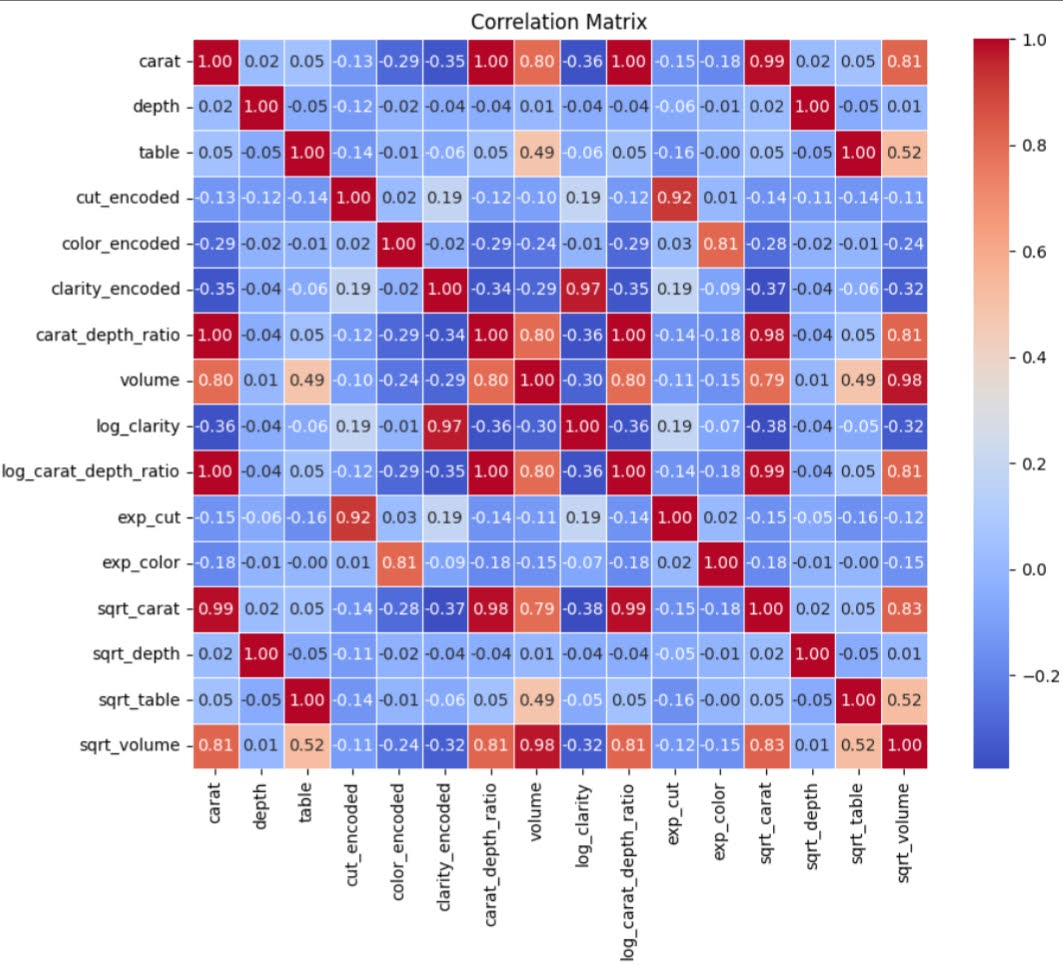

1. **Finding's Importance**: Regularization techniques such as Ridge and Lasso can prevent overfitting by penalizing large coefficients and/or shrinking some coefficients to 0 [6]. However, overly strong regularization may lead to underfitting and loss of important predictive relationships.

1. **Experiment Setup**: We used five-fold cross-validation with the Linear Regression model as a baseline and measured performance using MAE. Ridge regression was tested with different alpha values (a = 0.001, 0.01, 0.1, 1.0), while Lasso was evaluated with various regularization strengths.

1. **Results**: Linear Regression performed best compared to Ridge and Lasso, achieving the lowest MAE. Ridge regression with lower alpha values increased MAE by 10, while Lasso further degraded performance. As a result, we selected Linear Regression for the final model.


1. **Title**: Post-Processing Transformations for Distribution Matching
1. **Idea Discovery**: The predicted price distribution did not align with the training data. We used quantile-based transformation using interp1d to adjust the distribution.
1. **Finding's Importance**: Ensuring aligned price distributions prevents extreme outlier predictions and improves model stability.

1. **Experiment Setup**: We used five-fold cross-validation with the Linear Regression model as a baseline and measured performance using MAE.
1. **Results**: Without post-processing, the MAE was 648.21. With post-processing, the MAE improved to 627.1. Post-processing reduced the MAE by ~15 points.

<font color=green><h3><b>$\zeta$. References</b></h3>
<details>
  <summary>Instructions</summary>
  <div>

1. Cite your sources to help your peers learn from these (and to avoid plagiarism).
1. HOML textbook should be cited, since we used it in this week's learning.
1. Use Google Scholar to draw [APA](https://en.wikipedia.org/wiki/American_Psychological_Association) citation format for books and publications.
1. Cite [StackOverflow](https://stackoverflow.com/), YouTube videos, package docs, open-access textbooks/publicaitons and other meaningful internet resources that you used.
1. We may reward exceptional and meaningful citations (not just a list of [SKL](https://scikit-learn.org/stable/)/[TF](https://www.tensorflow.org/) manual pages and a list of articles.) For example, if you used an idea from a publication, indicate it in TGP with a number that corresponds to its reference in References.

</div> </details>
</font>


1.   *Guide to Understanding Diamond Grading Reports.* GIA Gemological
Institute of America Inc. (n.d.). https://www.gia.edu/doc/GIA_GuidetoUnderstandingReports_DiamondGradingReport.pdf
2.   Géron, A. (2019). *Hands-on machine learning with Scikit-Learn, Keras, and Tensorflow*  (2nd ed.). O’Reilly.
3.   *Transforming skewed data: How to choose the right transformation for your distribution.* Anatomise Biostats: Biostatistics & Bioinformatics Services. (2017, June 28). https://anatomisebiostats.com/biostatistics-blog/transforming-skewed-data/
4.   *Understanding diamond table and depth, Diamond Cut Education*. Brilliance. (n.d.). https://www.brilliance.com/education/diamonds/depth-table
5.   *Diamond Anatomy: Cut, Fire, Brilliance, and Scintillation.* Diamond Ateliers. (n.d.). https://www.diamondateliers.com/blog/diamond-anatomy-cut-fire-brilliance-and-scintillation/
6.   Tibshirani, R. (1996). R*egression shrinkage and selection via the lasso. Journal of the Royal Statistical Society* Series B: Statistical Methodology, 58(1), 267–288. https://doi.org/10.1111/j.2517-6161.1996.tb02080.x

<font size=5>⌛</font> <strong><font color=green size=5>Do not exceed competition's runtime limit! Do not write code outside TGP</font></strong>
<hr color=green size=40>

In [ ]:
tmr.ShowTime()    # measure Colab's runtime. Do not remove. Keep as the last cell in your notebook.

Runtime is 56 sec


<details>
  <summary><font size=5><b>💡Starter Ideas</b></font></summary>
  <div>
  
1. Tune model hyperparameters
1. Try to linear and non-linear feature normalization: shift/scale, log, divide features by features (investigate scatterplot matrix)
1. Try higher order feature interactions ($x_i^a$, $x_ix_j$, ...) to identify new key features or their linear combinations. With too many features you can use a smaller subsample or reduce dimensionality of feature space using [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [tSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html), or [UMAP](https://umap-learn.readthedocs.io/en/latest/).
1. Do a thorough EDA and understand non-linear relation in I/O. Are any interactions more special than others (E.g. is diamond *volume* a better predictor?)
1. If you note a shift in trend for any predictors, try building a model for each trend.
1. Evaluate predictions and focus on poorly predicted "groups". Can they be identified and modeled separately?
1. Do scatter plots show piecewise linear shape? Can a separate linear model be used on each support of approximately linear X-Y relation?
1. How are categorical features treated by the SKLearn models? Is there a [better way](https://www.google.com/search?q=ways+to+encode+categorical+data) to encode these (perhaps, ordinal) features?
  1. E.g. you could replace codes (or groups of codes) with their frequencies, which may capture the implied "distance" or rarity between category levels.
  1. If encoding ordinal features with integers, should non-equidistant values be considered?
1. Learn about [modeling price of a diamond](https://www.google.com/search?q=machine+learning+model+price+diamond).
1. Try post-processing: shifting/scaling/transforming the distribution of predicted prices `pY` to match the distribution of training prices `tY`

</div> </details>